# Tuần 07 — Thực hành DBSCAN: 3 bài

Demo `07_Demo-DBSCAN.ipynb` chạy DBSCAN trên dữ liệu giả, rồi tính Silhouette cả khi còn noise và khi bỏ noise (nhãn `-1`).

File này có **3 bài**, cùng 3 bộ Kaggle với `06_TH-kMeans.ipynb`. Cả 3 bài đều làm. Dùng `sklearn.cluster.DBSCAN`.

DBSCAN không nhận `K`. Hai tham số là `eps` và `min_samples`. Nhãn `-1` là nhiễu, không phải một cụm.

Fit `StandardScaler` trên toàn bộ feature. `eps` đọc trên dữ liệu **đã chuẩn hóa**.

| Bài | Bộ dữ liệu | Link | File |
|---|---|---|---|
| 1 | Mall Customer Segmentation | https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python | `data/Mall_Customers.csv` |
| 2 | Unsupervised Learning on Country Data | https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data | `data/Country-data.csv` |
| 3 | Wholesale Customers | https://www.kaggle.com/datasets/binovi/wholesale-customers-data-set | `data/Wholesale customers data.csv` |


In [10]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


In [17]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")

print("Path to dataset files:", path)

100%|██████████| 1.55k/1.55k [00:00<00:00, 413kB/s]

Extracting files...
Path to dataset files: C:\Users\huynh\.cache\kagglehub\datasets\vjchoudhary7\customer-segmentation-tutorial-in-python\versions\1


In [18]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rohan0301/unsupervised-learning-on-country-data")

print("Path to dataset files:", path)

100%|██████████| 5.21k/5.21k [00:00<?, ?B/s]

Extracting files...
Path to dataset files: C:\Users\huynh\.cache\kagglehub\datasets\rohan0301\unsupervised-learning-on-country-data\versions\2


In [19]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("binovi/wholesale-customers-data-set")

print("Path to dataset files:", path)

100%|██████████| 6.85k/6.85k [00:00<?, ?B/s]

Extracting files...
Path to dataset files: C:\Users\huynh\.cache\kagglehub\datasets\binovi\wholesale-customers-data-set\versions\1


## Phần chung

Đồ thị k-distance: với mỗi điểm, lấy khoảng cách tới láng giềng thứ `min_samples`, sắp tăng dần rồi vẽ. `eps` nằm ở chỗ đường bắt đầu dựng đứng.

Silhouette chỉ tính khi còn ít nhất 2 cụm. Bản "bỏ noise" loại các điểm nhãn `-1` trước, giống mục 2.3 của demo.


In [20]:
def ve_k_distance(X_scaled, min_samples=5):
    nn = NearestNeighbors(n_neighbors=min_samples)
    nn.fit(X_scaled)
    dists, _ = nn.kneighbors(X_scaled)
    kth = np.sort(dists[:, -1])
    plt.figure(figsize=(6, 4))
    plt.plot(kth)
    plt.xlabel('điểm, đã sắp theo khoảng cách')
    plt.ylabel(f'khoảng cách tới láng giềng thứ {min_samples}')
    plt.grid(True)
    plt.show()
    return kth


def tom_tat(labels):
    labels = np.asarray(labels)
    n_noise = int(np.sum(labels == -1))
    cum = [c for c in np.unique(labels) if c != -1]
    print('số cụm:', len(cum))
    print('số nhiễu:', n_noise)
    print(np.unique(labels, return_counts=True))


def silhouette_hai_cach(X_scaled, labels):
    labels = np.asarray(labels)
    cum = [c for c in np.unique(labels) if c != -1]
    if len(cum) < 2:
        print('Chưa đủ 2 cụm để tính Silhouette. Đổi eps hoặc min_samples.')
        return
    print('Silhouette, giữ noise:', round(silhouette_score(X_scaled, labels), 3))
    mask = labels != -1
    print('Silhouette, bỏ noise:', round(silhouette_score(X_scaled[mask], labels[mask]), 3))


---

# Bài 1 — Khách hàng trung tâm thương mại

Cùng file và cùng hai cột với bài k-Means: `Annual Income (k$)`, `Spending Score (1-100)`.

Chuẩn hóa, vẽ k-distance với `min_samples=5`, chọn `eps` ở khuỷu. Fit DBSCAN. Vẽ scatter: cụm tô màu, nhiễu để màu đen dấu `x`.

Gợi ý khi chỉnh: ra toàn `-1` thì tăng `eps`. Ra đúng 1 cụm và không còn nhiễu thì giảm `eps`. Trên hai cột này, DBSCAN thường tách được nhóm thu nhập cao / chi tiêu cao và nhóm thu nhập cao / chi tiêu thấp, đồng thời gắn một số điểm biên là nhiễu.


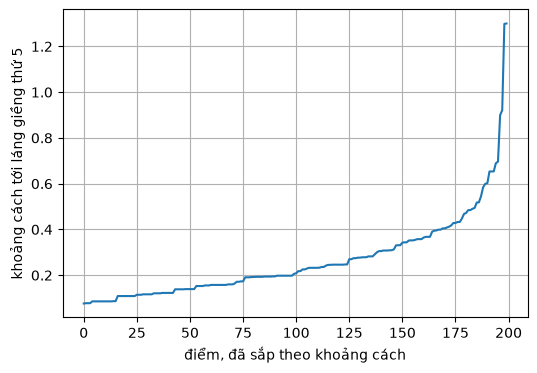

array([0.07633886, 0.07764312, 0.07764312, 0.07764312, 0.08564307,
       0.08564307, 0.08564307, 0.08564307, 0.08564307, 0.08564307,
       0.08564307, 0.08564307, 0.08564307, 0.08564307, 0.08651797,
       0.08651797, 0.10888561, 0.10888561, 0.10888561, 0.10888561,
       0.10888561, 0.10888561, 0.10888561, 0.10888561, 0.10888561,
       0.11450829, 0.11450829, 0.11450829, 0.11646468, 0.11646468,
       0.11646468, 0.11646468, 0.11646468, 0.12091014, 0.12091014,
       0.12091014, 0.12091014, 0.12255989, 0.12255989, 0.12255989,
       0.12255989, 0.12255989, 0.12255989, 0.13834957, 0.13834957,
       0.13834957, 0.13834957, 0.13834957, 0.13925388, 0.13925388,
       0.13925388, 0.13925388, 0.13925388, 0.15267772, 0.15267772,
       0.15267772, 0.15267772, 0.15528624, 0.15528624, 0.15528624,
       0.15753602, 0.15753602, 0.15753602, 0.15753602, 0.15753602,
       0.15753602, 0.15753602, 0.15753602, 0.15990848, 0.15990848,
       0.15990848, 0.16332841, 0.17128613, 0.17128613, 0.17303

In [15]:
mall = pd.read_csv('data/Mall_Customers.csv')
cot = ['Annual Income (k$)', 'Spending Score (1-100)']
X = mall[cot].to_numpy(dtype=float)
X_scaled = StandardScaler().fit_transform(X)

ve_k_distance(X_scaled, min_samples=5)


số cụm: 2
số nhiễu: 8
(array([-1,  0,  1]), array([  8, 157,  35]))


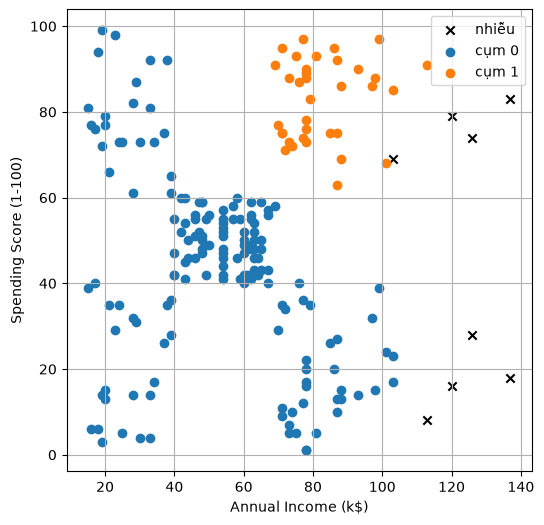

Silhouette, giữ noise: 0.35
Silhouette, bỏ noise: 0.388


In [21]:
# TODO: đọc eps từ đồ thị k-distance
eps = 0.5
min_samples = 5

labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_scaled)
tom_tat(labels)

plt.figure(figsize=(6, 6))
for cum in np.unique(labels):
    pts = X[labels == cum]
    if cum == -1:
        plt.scatter(pts[:, 0], pts[:, 1], c='black', marker='x', label='nhiễu')
    else:
        plt.scatter(pts[:, 0], pts[:, 1], label=f'cụm {cum}')

plt.xlabel(cot[0])
plt.ylabel(cot[1])
plt.legend()
plt.grid(True)
plt.show()

silhouette_hai_cach(X_scaled, labels)

**Nộp kèm bài 1**

1. `eps` và `min_samples` bạn dùng? Có bao nhiêu cụm, bao nhiêu điểm nhiễu?
2. So với k-Means trên cùng hai cột: điểm khác nhìn thấy trên hình là gì?
3. Silhouette khi giữ noise và khi bỏ noise, số nào cao hơn? Vì sao demo cũng tính lại sau khi bỏ noise?


In [ ]:
# Bài 1
# 1.
#  eps, min_samples và kết quả DBSCAN:
# eps: Theo đồ thị k-distance.
# min_samples = 5.
# Số cụm: 2.
# Số điểm nhiễu: 8.
# Silhouette giữ noise: 0.35; bỏ noise: 0.388.

# 2.k-Means chia tất cả điểm vào các cụm, còn DBSCAN có thể xác định điểm nhiễu và không cần xác định trước số cụm.

# 3.Silhouette khi bỏ noise cao hơn (0.388 > 0.35). Demo tính lại sau khi bỏ noise để đánh giá chất lượng phân cụm chính xác hơn, không bị ảnh hưởng bởi các điểm nhiễu.


---

# Bài 2 — Quốc gia

Cùng file `Country-data.csv`. Bỏ cột `country` khỏi `X`, chuẩn hóa 9 cột số.

Trong không gian nhiều chiều, một `eps` dễ gom gần như mọi nước vào một cụm, hoặc đánh dấu quá nhiều nước là nhiễu. Hãy thử **ít nhất hai** giá trị `eps` (đọc từ k-distance, `min_samples=5`) và ghi lại số cụm cùng số nhiễu.

Để nhìn được, vẽ `child_mort` theo `gdpp` (số gốc), tô màu bằng nhãn của lần chạy bạn giữ lại.


In [ ]:
country = pd.read_csv('data/Country-data.csv')
cot_so = [c for c in country.columns if c != 'country']
X_scaled = StandardScaler().fit_transform(country[cot_so].to_numpy(dtype=float))

ve_k_distance(X_scaled, min_samples=5)


In [ ]:
# TODO: thử ít nhất 2 eps, in tom_tat cho mỗi lần
# Giữ lại một eps để vẽ
eps = ???
labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X_scaled)
tom_tat(labels)

plt.figure(figsize=(7, 5))
for cum in np.unique(labels):
    pts = country.loc[labels == cum]
    if cum == -1:
        plt.scatter(pts['gdpp'], pts['child_mort'], c='black', marker='x', label='nhiễu')
    else:
        plt.scatter(pts['gdpp'], pts['child_mort'], label=f'cụm {cum}')
plt.xlabel('gdpp')
plt.ylabel('child_mort')
plt.legend()
plt.grid(True)
plt.show()


**Nộp kèm bài 2**

1. Hai giá trị `eps` bạn thử, và số cụm / số nhiễu của mỗi lần?
2. `eps` bạn giữ lại gắn những nước nào vào nhiễu? Kể 3 tên.
3. Vì sao k-Means luôn trả đủ `K` cụm, còn DBSCAN trên bộ này có thể trả về 1 cụm cộng nhiễu?


In [ ]:
# Bài 2
# 1.
# 2.
# 3.


---

# Bài 3 — Khách sỉ

Cùng 6 cột chi tiêu với bài k-Means. Không đưa `Channel` và `Region` vào `X`. Chuẩn hóa.

Chi tiêu có vài khách rất lớn so với phần còn lại. DBSCAN thường gắn họ là nhiễu (`-1`) thay vì kéo tâm cụm đi, khác k-Means.

Chọn `eps` bằng k-distance (`min_samples=5`). In số cụm, số nhiễu, Silhouette hai cách, và `crosstab` giữa nhãn với `Channel`.


In [ ]:
ws = pd.read_csv('data/Wholesale customers data.csv')
cot_chi = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
X_scaled = StandardScaler().fit_transform(ws[cot_chi].to_numpy(dtype=float))

ve_k_distance(X_scaled, min_samples=5)


In [ ]:
eps = ???
labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X_scaled)
tom_tat(labels)
silhouette_hai_cach(X_scaled, labels)
print(pd.crosstab(labels, ws['Channel'], rownames=['cum'], colnames=['Channel']))


**Nộp kèm bài 3**

1. `eps` bạn chọn? Bao nhiêu điểm bị coi là nhiễu?
2. Nhãn `-1` có nằm dồn ở một `Channel` không?
3. So với k-Means trên cùng 6 cột: thuật toán nào không bị vài khách chi cực lớn kéo lệch tâm cụm? Giải thích bằng cách mỗi thuật toán tạo cụm.


In [ ]:
# Bài 3
# 1.
# 2.
# 3.
